# **LABORATORIO 6: VALIDACIÓN CRUZADA Y MÉTRICAS DE EVALUACIÓN**

## **PARTE A: Preparación de los datos**

### **Separación del Dataframe en variables numéricas y no numéricas**

In [1]:
# Importación de librerías
import pandas as pd # Trabajar con datos estructurados
import numpy as np
from IPython.display import display, HTML # Visualización de objetos
import matplotlib.pyplot as plt # Visualización de gráficos
import seaborn as sns # Visualización de gráficos
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Lectura de la data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
data = pd.read_csv(url, header = None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
# Renombramiento de las columnas del dataframe
data.columns = ["id", "clump_thickness", "size_uniformity", "shape_uniformity", "marginal_adhesion", "epithelial_size",
               "bare_nucleoli", "bland_chromatin", "normal_nucleoli", "mitoses", "class"]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 699 non-null    int64 
 1   clump_thickness    699 non-null    int64 
 2   size_uniformity    699 non-null    int64 
 3   shape_uniformity   699 non-null    int64 
 4   marginal_adhesion  699 non-null    int64 
 5   epithelial_size    699 non-null    int64 
 6   bare_nucleoli      699 non-null    object
 7   bland_chromatin    699 non-null    int64 
 8   normal_nucleoli    699 non-null    int64 
 9   mitoses            699 non-null    int64 
 10  class              699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [4]:
# Se transforman los datos para separar el dataframe en variables numéricas y no numéricas

# Variable 'bare_nucleoli':
# Se reemplazan los valores nulos (?) por la mediana
data['bare_nucleoli'] = data['bare_nucleoli'].replace("?",pd.NA)
mediana = data['bare_nucleoli'].median()
data['bare_nucleoli'] = data['bare_nucleoli'].fillna(mediana)

# Se convierte la variable a tipo entero
data['bare_nucleoli'] = data['bare_nucleoli'].astype(int)

# Variable 'class':
# Se modifican las categorías '2' y '4' por valores binarios: '0' corresponde a benigno y '1' a maligno
data['class'] = data['class'].apply(lambda x: 0 if x == 2 else 1)

# Se convierte la variable a tipo categórica
data['class'] = data['class'].astype('category')

# Variable 'id':
# Se convierte la variable a tipo cadena
data['id'] = data['id'].astype(str)

In [5]:
# Se separa el dataframe en variables numéricas y no numéricas
data_numeric = data.select_dtypes(include = 'number')
data_no_numeric = data.select_dtypes(exclude = 'number')

# Se muestra el dataframe de variables numéricas
display(HTML("<h4>DataFrame de variables numéricas</h4>"))
display(data_numeric.head())

# Se muestra el dataframe de variables no numéricas
display(HTML("<h4>DataFrame de variables no numéricas</h4>"))
display(data_no_numeric.head())

,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1


,id,class
0,1000025,0
1,1002945,0
2,1015425,0
3,1016277,0
4,1017023,0


### **Tratamiento de outliers**

#### **Análisis exploratorio: Boxplot**

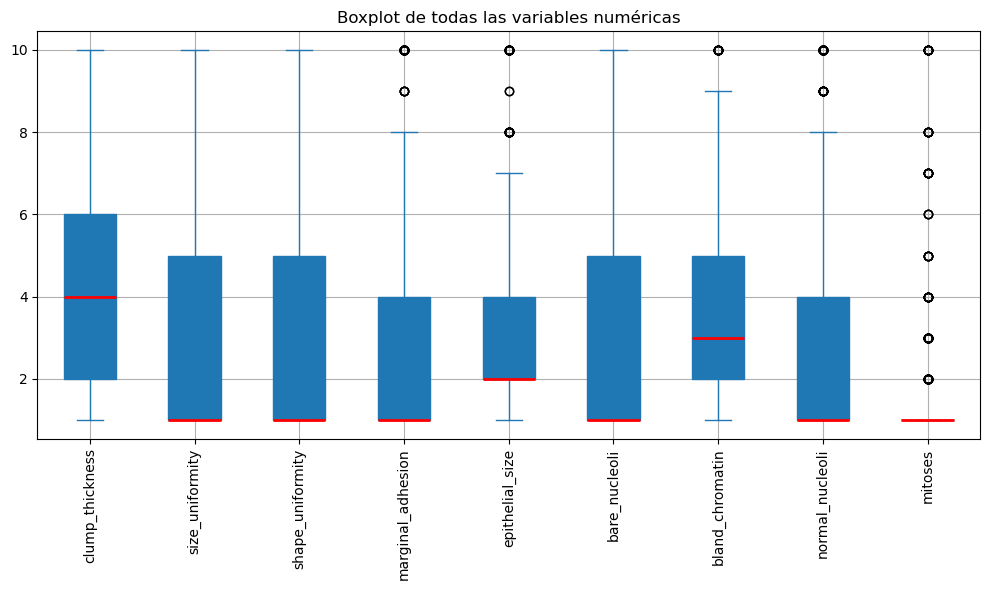

In [6]:
# Se mostrarán los diagramas de caja de todas las variables numéricas para visualizar outliers
boxplot = data_numeric.plot(kind='box', patch_artist=True, grid=True, figsize=(10, 6))

# Resaltar estilo de líneas de la mediana
for line in boxplot.lines[4::6]:  # En matplotlib, cada boxplot tiene 6 líneas. La 5ta es la mediana.
    line.set_color('red') # Formato de color
    line.set_linewidth(2)  # Formato de grosor

# Mostrar gráfica
plt.title('Boxplot de todas las variables numéricas') # Título de la gráfica
plt.xticks(rotation=90) # Rotación de las etiquetas del eje x
plt.tight_layout() # Se ajusta automáticamente los espacios de los elementos del gráfico
plt.show()

Se observan datos atípicos en el boxplot (fuera de 1.5 veces del rango intercuartil) en las variables marginal_adhesion, epithelial_size, bland_chromatin, normal_nucleoli y en mitoses. Se realiza un análisis mutivariado para evaluar si efectivamente corresponderían a valores atípicos. Para utilizar el criterio de las distancias de Mahalanobis y umbrales de Chi-cuadrado, una de las suposiciones más importantes es que los datos deben seguir una distribución normal multivariada. Para ello, se visualiza gráficamente la distribución de los datos.

#### **Análisis exploratorio: Gráficas de dispersión y densidad**

Text(0.5, 1.03, 'Distribución de variables numéricas')

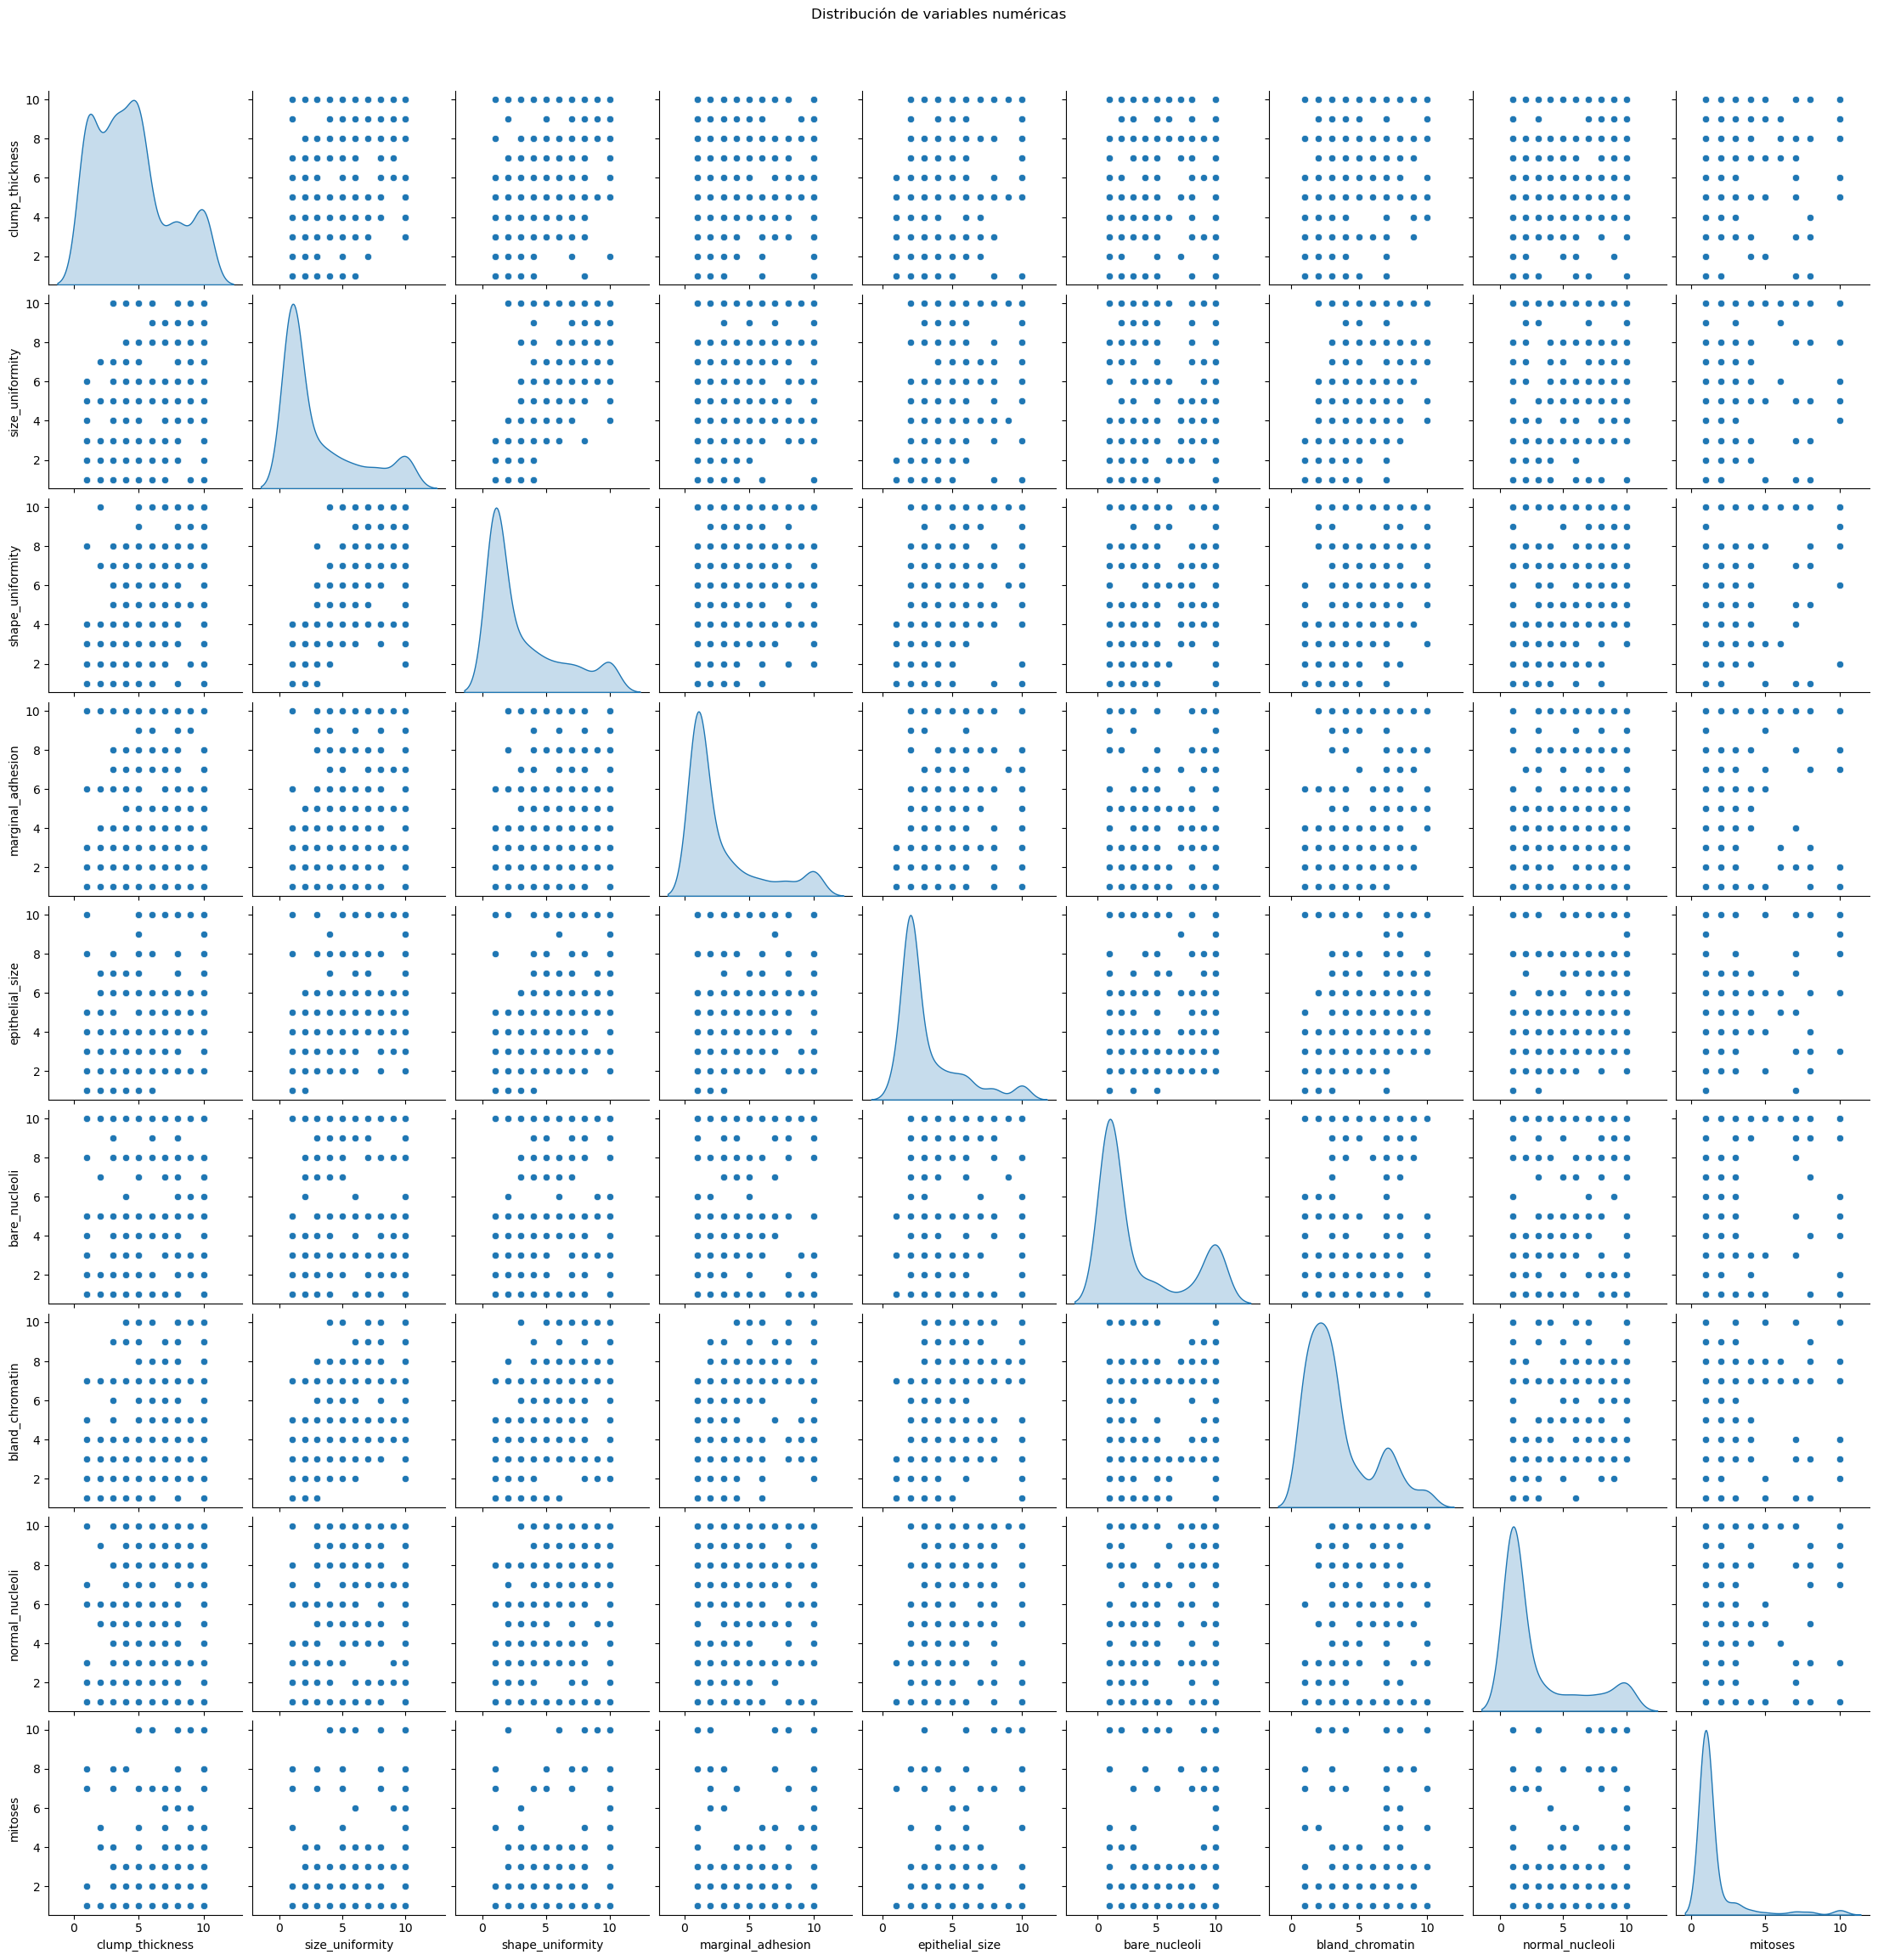

In [7]:
# Se genera una matriz de gráficas de dispersión y densidad de las variables
sns.pairplot(data_numeric, diag_kind="kde") # Diagonal con gráfica de densidad (por defecto histograma)
plt.suptitle("Distribución de variables numéricas", y=1.03)

In [8]:
""" Se calcula numéricamente la asimetría de las distribuciones con la función skew. 

Se interpreta los valores de la siguiente manera:
Valor de Skew | Interpretación
≈ 0 | Simétrica
> 0 y ≤ 0.5 | Leve asimetría positiva
> 0.5 y ≤ 1 | Moderada asimetría positiva
> 1 | Fuerte asimetría positiva
< 0 y ≥ -0.5 | Leve asimetría negativa
< -0.5 y ≥ -1 | Moderada asimetría negativa
< -1 | Fuerte asimetría negativa
"""
data_numeric.skew()

clump_thickness      0.592859
size_uniformity      1.233137
shape_uniformity     1.161859
marginal_adhesion    1.524468
epithelial_size      1.712172
bare_nucleoli        1.025347
bland_chromatin      1.099969
normal_nucleoli      1.422261
mitoses              3.560658
dtype: float64

#### **Transformación logarítmica**

In [9]:
# Se aplica transformación logarítmica a todas aquellas variables con skew mayor a 1 (fuerte asimetría positiva)
skew_values = data_numeric.skew() # Se almacenan los valores skew
data_transformed = data_numeric.copy() #  Copia del Dataframe original

for col in skew_values.index: # Se itera sobre los nombres de las columnas (índices del skew)
    if abs(skew_values[col]) > 1:
        data_transformed[col] = np.log(data_transformed[col])  # usaremos log1p para valores > 0

# Se muestra el Dataframe con las variables transformadas selectivamente
data_transformed.head()

,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses
0,5,0.000000,0.000000,0.000000,0.693147,0.000000,1.098612,0.000000,0.0
1,5,1.386294,1.386294,1.609438,1.945910,2.302585,1.098612,0.693147,0.0
2,3,0.000000,0.000000,0.000000,0.693147,0.693147,1.098612,0.000000,0.0
3,6,2.079442,2.079442,0.000000,1.098612,1.386294,1.098612,1.945910,0.0
4,4,0.000000,0.000000,1.098612,0.693147,0.000000,1.098612,0.000000,0.0


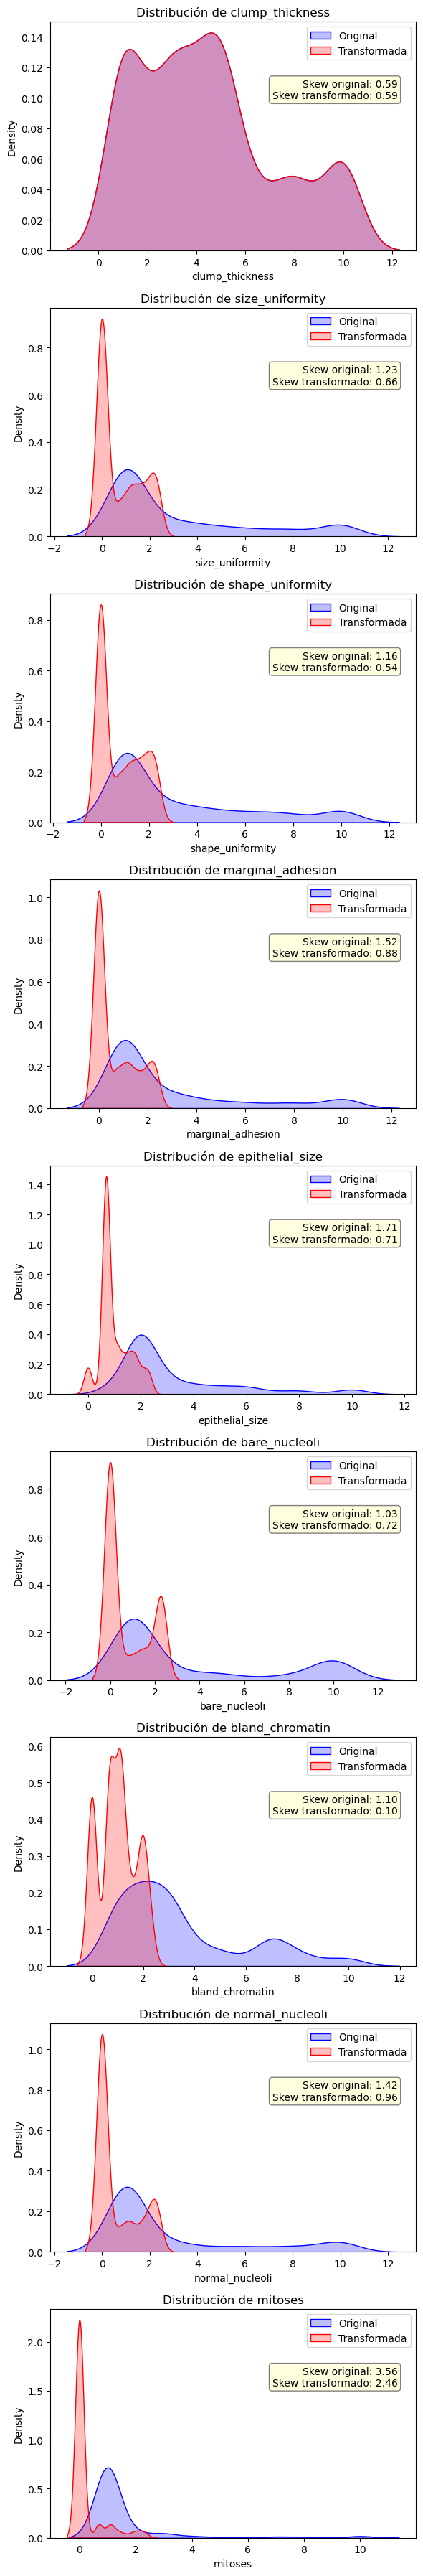

In [10]:
# Se visualiza gráficamente el impacto de la transformación de la data

# Calcular skew para cada variable
skew_original = data_numeric.skew()
skew_transformed = data_transformed.skew()

# Número de variables
n_vars = len(data_numeric.columns)

# Crear figura con los subgráficas (una columna y una fila por variable)
fig, axes = plt.subplots(n_vars, 1, figsize=(6, 4 * n_vars), sharex=False)

# Iterar sobre las variables
for i, col in enumerate(data_numeric.columns):
    sns.kdeplot(data_numeric[col], color='blue', label='Original', shade=True, ax=axes[i]) # Gráfica de densidad de data original
    sns.kdeplot(data_transformed[col], color='red', label='Transformada', shade=True, ax=axes[i]) # Gráfica de densidad de data transformada

    axes[i].set_title(f'Distribución de {col}')
    axes[i].legend()

    # Crear texto con skew
    skew_info = f"Skew original: {skew_original[col]:.2f}\nSkew transformado: {skew_transformed[col]:.2f}"

    # Añadir recuadro con skew
    axes[i].text(
        0.95, 0.75, skew_info,
        transform=axes[i].transAxes, # Coordenadas relativas al gráfico
        fontsize=10,
        verticalalignment='top', # Alineamiento vertical
        horizontalalignment='right', # Alineamiento horizontal
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray') # Recuadro con fondo y borde
    )

plt.tight_layout()
plt.show()

#### **Detección de outliers con distancias de Mahalanobis y umbrales de Chi-cuadrado**

Si los datos siguen una distribución normal multivariada, entonces la distancia de Mahalanobis al cuadrado de cada punto con respecto a la media sigue una distribución chi-cuadrado, con grados de libertad iguales al número de variables. El umbral se define como el valor límite de esa distribución, y representa el punto a partir del cual se considera que un dato es atípico (outlier). Los datos cuya distancia de Mahalanobis al cuadrado supere ese umbral se encuentran fuera del rango esperado con una cierta probabilidad (por ejemplo, 1% si usamos un nivel de confianza del 99%).

In [11]:
from scipy.stats import chi2
from scipy.spatial.distance import cdist

# Se calcula la media, la matriz de covarianza y su inversa
mean = data_transformed.mean(axis=0)
cov_matrix = np.cov(data_transformed.T) # Se transpone el Dataframe (se requiere que las variables esten en la las filas y las observaciones en columnas)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Distancia de Mahalanobis
mahalanobis_distances = cdist(data_transformed, mean.values.reshape(1, -1), metric='mahalanobis', VI=inv_cov_matrix).flatten()

# Se crea y se muestra una copia del Dataframe con las distancias de Mahalanobis
data_dist_mah = data_transformed.copy()
data_dist_mah['mahalanobis'] = mahalanobis_distances
display(HTML("<h4>DataFrame con distancias de Mahalanobis</h4>"))
display(data_dist_mah.head())

# Se muestran los estadísticos descriptivos de las distancias obtenidas
display(HTML("<h4>Estadísticos de distancias de Mahalanobis</h4>"))
display(data_dist_mah['mahalanobis'].describe())

# Se define y se muestra el umbral en función del número de variables df (grados de libertad)
display(HTML("<h4>Parámetros de umbral de Chi-cuadrado</h4>"))
threshold = chi2.ppf(0.99, df=data_transformed.shape[1])  # Umbral para 99% de confianza
display(f"Umbral de Chi-cuadrado: {threshold:.2f}")

# Se identifican y se eliminan los outliers
outliers = mahalanobis_distances > threshold # Array booleano
display(f"Se han detectado {outliers.sum()} outliers.")

# Filtrar los datos sin los outliers
data_clean = data_transformed[~outliers]

# Verificar la forma de los datos antes y después
display(f"Tamaño original: {data_transformed.shape}")
print(f"Tamaño después de eliminar outliers: {data_clean.shape}")


,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,mahalanobis
0,5,0.000000,0.000000,0.000000,0.693147,0.000000,1.098612,0.000000,0.0,1.919609
1,5,1.386294,1.386294,1.609438,1.945910,2.302585,1.098612,0.693147,0.0,3.225592
2,3,0.000000,0.000000,0.000000,0.693147,0.693147,1.098612,0.000000,0.0,1.783581
3,6,2.079442,2.079442,0.000000,1.098612,1.386294,1.098612,1.945910,0.0,4.158970
4,4,0.000000,0.000000,1.098612,0.693147,0.000000,1.098612,0.000000,0.0,2.523398


count    699.000000
mean       2.775062
std        1.134901
min        1.016251
25%        1.788959
50%        2.647858
75%        3.539927
max        6.896347
Name: mahalanobis, dtype: float64

'Umbral de Chi-cuadrado: 21.67'

'Se han detectado 0 outliers.'

'Tamaño original: (699, 9)'

Tamaño después de eliminar outliers: (699, 9)


In [12]:
data_dist_mah['mahalanobis'].describe()

count    699.000000
mean       2.775062
std        1.134901
min        1.016251
25%        1.788959
50%        2.647858
75%        3.539927
max        6.896347
Name: mahalanobis, dtype: float64

### **Separación en data de entrenamiento y prueba**

In [13]:
from sklearn.model_selection import train_test_split

# Se determina la variable objetivo y las variables predictoras
X = data_clean # Variables numéricas predictoras
y = data_no_numeric['class'] # Variable objetivo categórica

# Se divide la data aleatoriamente en el 75% para el entrenamiento y 25% para la evaluación
# Se asigna un número semilla para la reproducibilidad (random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## **PARTE B: Modelado**

### **Determinación gráfica de la cantidad de vecinos más cercanos**

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

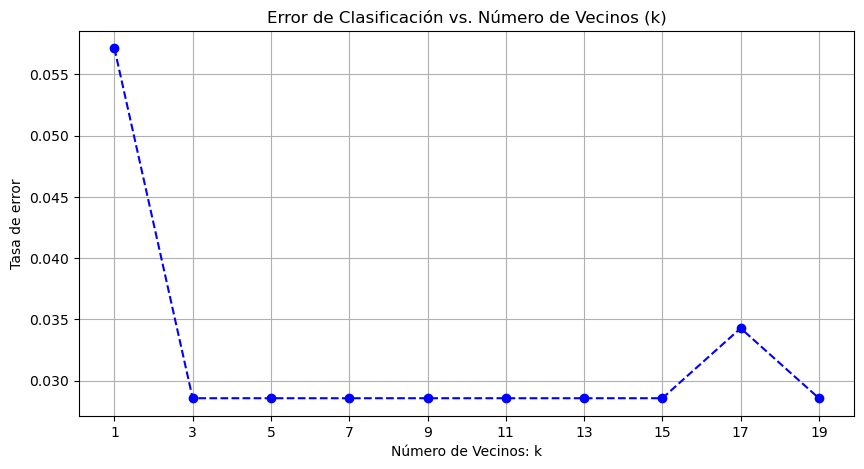

In [15]:
# Se determina el error (1 -  Exactitud) del modelo para distintos valores de k
error_rates = []
k_range = range(1, 21, 2) # Se consideran valores impares de k

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, pred_k)
    error_rates.append(error)

# Se grafica el error vs. k
plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rates, marker='o', linestyle='--', color='b')
plt.title('Error de Clasificación vs. Número de Vecinos (k)')
plt.xlabel('Número de Vecinos: k')
plt.ylabel('Tasa de error')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Se observa que para valores de k impares entre 3 y 15 no hay variación del error. Se toma el valor de K=5 para el modelo.

### **Modelo de k-NN con k=5**

In [26]:
# Se genera el modelo de k-NN
k_mod = 5
knn = KNeighborsClassifier(n_neighbors=k_mod) 
knn.fit(X_train, y_train) # Se ajusta el modelo a la data de entrenamiento
y_pred = knn.predict(X_test) # Se predicen los valores para la data de prueba

# Matriz de confusión
'''
Se considera negativo: Benigno (0)
Se considera positivo: Maligno (1)
La matriz de confusión en sklearn toma (1) como positivo por defecto
'''
conf_matrix = confusion_matrix(y_test, y_pred) # Se genera la matriz comparando los valores predichos y los reales de la data de prueba
tn, fp, fn, tp = conf_matrix.ravel() # Extraer los valores de la matriz de confusión

# Se muestra la matriz de confusión como Dataframe
df_conf = pd.DataFrame(conf_matrix, 
                     index=['Real: Benigno (0)', 'Real: Maligno (1)'], 
                     columns=['Predicho: Benigno (0)', 'Predicho: Maligno (1)'])
display(HTML("<h4>Matriz de confusión</h4>"))
display(df_conf)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)

# Mostrar resultados
display(HTML("<h4>Métricas del modelo</h4>"))
display(f"Exactitud: {accuracy:.3f}")
display(f"Precisión: {precision:.3f}")
display(f"Sensibilidad (Recall): {recall:.3f}")
display(f"Especificidad: {specificity:.3f}")
display(f"Puntuación F1: {f1:.3f}")


,Predicho: Benigno (0),Predicho: Maligno (1)
Real: Benigno (0),116,2
Real: Maligno (1),3,54


'Exactitud: 0.971'

'Precisión: 0.964'

'Sensibilidad (Recall): 0.947'

'Especificidad: 0.983'

'Puntuación F1: 0.956'

1) La exactitud es la proporción de predicciones correctas en comparación con el total de predicciones. En este caso, el 97% de las predicciones fueron correctas. Este es un buen resultado, pero la exactitud no es suficiente por sí sola cuando las clases están desbalanceadas, ya que podría estar siendo influenciada por la clase mayoritaria.
2) La precisión mide qué tan bien el modelo predice la clase positiva (maligno). Un 96% de las veces que el modelo predijo que el tumor era maligno (1), en realidad era maligno. Este es un buen resultado, lo que significa que el modelo tiene pocas falsas alarmas. Esto es importante en aplicaciones médicas, donde los falsos positivos pueden ser costosos (por ejemplo, tratamientos innecesarios).
3) La sensibilidad (recall) mide qué tan bien el modelo detecta la clase positiva (maligno). Un 95% de los tumores malignos fueron correctamente identificados como tales. Esto es una excelente puntuación, ya que indica que el modelo es muy eficaz en detectar tumores malignos. En el contexto médico, es crucial minimizar los falsos negativos (tumores malignos que se clasifican como benignos), ya que esto podría llevar a diagnósticos erróneos y retrasos en el tratamiento.
4) La especificidad mide qué tan bien el modelo identifica la clase negativa (benigno). Un 98% de los tumores benignos fueron correctamente identificados como tales. Este es un resultado excelente, lo que indica que el modelo tiene una alta capacidad para evitar falsos positivos (casos en los que el modelo clasifica erróneamente un tumor benigno como maligno). Esto es importante para evitar tratamientos innecesarios.
5) La puntuación F1 es la media armónica entre la precisión y la sensibilidad. Una puntuación de 0.96 indica un buen balance entre ambos aspectos: el modelo tiene tanto una buena capacidad para detectar tumores malignos como una baja tasa de falsos positivos.

## **PARTE C: Balanceo de clases mediante técnica SMOTE**

In [18]:
from imblearn.over_sampling import SMOTE

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [27]:
# Generar el modelo k-NN con el conjunto de entrenamiento balanceado
k_mod = 5
knn = KNeighborsClassifier(n_neighbors=k_mod)
knn.fit(X_train_smote, y_train_smote)  # Entrenar con el conjunto balanceado
y_pred_smote = knn.predict(X_test)  # Realizar predicciones con el conjunto de prueba

# Obtener la matriz de confusión
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)

# Extraer los valores de la matriz de confusión
tn_smote, fp_smote, fn_smote, tp_smote = conf_matrix_smote.ravel()

# Calcular métricas
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
specificity_smote = tn_smote / (tn_smote + fp_smote)
f1_smote = f1_score(y_test, y_pred_smote)


metrics_comparison = pd.DataFrame({
    'Modelo Original': [accuracy, precision, recall, specificity, f1],
    'Modelo con SMOTE': [accuracy_smote, precision_smote, recall_smote, specificity_smote, f1_smote]
}, index=['Exactitud', 'Precisión', 'Sensibilidad', 'Especificidad', 'Puntuación F1'])

# Redondear los valores a 3 decimales
metrics_comparison = metrics_comparison.round(3)

# Mostrar el DataFrame
display(metrics_comparison)

,Modelo Original,Modelo con SMOTE
Exactitud,0.971,0.977
Precisión,0.964,0.949
Sensibilidad,0.947,0.982
Especificidad,0.983,0.975
Puntuación F1,0.956,0.966


1) La exactitud del modelo con SMOTE mejora ligeramente de 0.971 a 0.977 (+0.006). Esto significa que el modelo balanceado tiene un rendimiento global ligeramente mejor.
2) La precisión disminuye de 0.964 a 0.949 (-0.015). Esto indica que el modelo está clasificando más tumores benignos como malignos (falsos positivos), lo que afecta la precisión.
3) La sensibilidad mejora significativamente de 0.947 a 0.982 (+0.035), lo cual es un gran beneficio. El modelo balanceado es más efectivo para detectar los casos positivos (tumores malignos), lo que es crucial en problemas médicos donde es más importante no perder un caso positivo.
4) La especificidad disminuye ligeramente de 0.983 a 0.975 (-0.008). Esto significa que, aunque el modelo con SMOTE es más sensible, puede estar identificando algunos casos benignos (0) como malignos (1), lo que reduce la capacidad del modelo para identificar correctamente los negativos.
5) La puntuación F1 mejora de 0.956 a 0.966 (+0.010), lo que refleja una mejora general en el balance entre precisión y sensibilidad.